In [3]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import random

In [46]:
def f(x):
    return 3*x**2 - 4*x + 5
# now what is the derivative of any x on this function?

In [47]:
f(3.0)

20.0

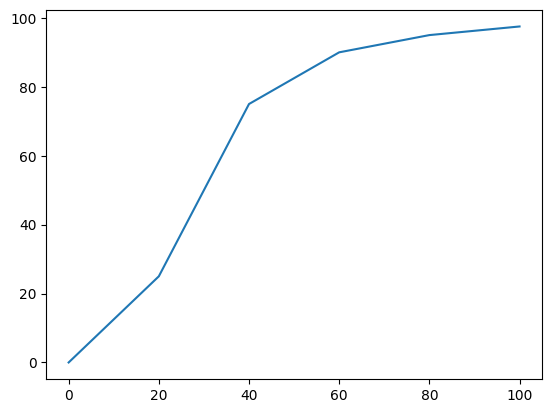

In [6]:
xd = (0, 20, 40, 60, 80, 100)
yd = (0, 25, 75, 90, 95, 97.5)

plt.plot(xd, yd)

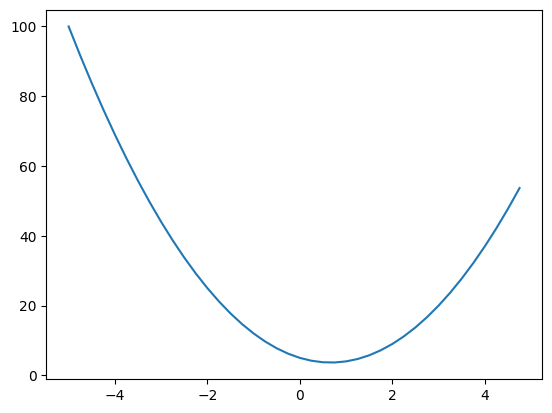

In [48]:
xs = np.arange(-5, 5, 0.25) 
# get the x values from -5, 5 excluding 5, with steps of .25

ys = f(xs)
# get the y values from inputting in the x values

plt.plot(xs, ys)

In [49]:
# Evaluating the derivative by taking small h
h = 0.00000001 # Don't use too many zeroes or it will be wrong
x = 2/3 # At that precise point, even if you nudge it a little, it will be zero

(f(x + h) - f(x)) / h # Slightly greater than 20

0.0

In [50]:
# Complex case
a = 2.0
b = -3.0
c = 10.0
d = a*b + c # Three scalar inputs
print(d)

4.0


In [51]:
# Looking at derivatives

h = 0.0001

# inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
# derivate of d with respect to a
# a += h # a will be bumped by h
# b += h # b will be bumped by h
c += h # c will be bumped by h
d2 = a*b + c

print('d1', d1) 
# d1 will be 4
print('d2', d2) 
# I think d2 will be slightly be smaller than 4 if a was bumped
# I think d2 will be slightly bigger if b was bumped
# I think d2 will be bigger if c was bumped, were just simply adding c
# Slope would be 1 if we add c
print('slope', (d2 - d1) / h)

d1 4.0
d2 4.0001
slope 0.9999999999976694


In [112]:
# Neural Networks
# Simple value object

class Value: # Takes a single scale of value that it warps and keeps track of
    def __init__(self, data, _children=(), _op='', label=""): # _children is tuple for convinience
        self.data = data
        self.grad = 0.0 # 0 means no effect
        # Time to codify the back propagation process automaticall through code
        self._backward = lambda: None # This backward function, by default it doesn't do anything
        # Leaf node case for example, theres nothing to do
        self._prev = set(_children) # turn into a set for efficiency
        self._op = _op
        self.label = label
    
    def __repr__(self): # repr returns the string, repr helps with printing out nicer expression in python
        return f"Value(data={self.data})"

# We have the add this function,
    def __add__(self, other): # double underscore methods to define operators
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def _backward(): # Chain rule
            self.grad += 1.0 * out.grad # Local derivative of self is 1.0 * out.grad
            other.grad += 1.0 * out.grad # Out grad will be simply copied into self grad and other grad
        out._backward = _backward

        return out
    
    def __radd__(self, other): # handles 0 + Value
        return self + other

# Implement multiply to recreate the derivative func from earlier
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward(): # chain rule for multiplication
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward

        return out
    
    def __rmul__(self, other):  # other * self
        return self * other     # rmul is the fall back, it's a check
        # 2 * a -> a * 2 in rmul
    
    def __neg__(self): # -self
        return self * -1
    
    def __sub__(self, other): # self - other
        return self + (-other)

    def __pow__(self, other): # Other is power, other is forced to be int or float
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self,),f'**{other}')

        def _backward():
            self.grad += other * (self.data ** (other - 1)) * out.grad# What is the chain rule for back propagating thru power func
        out._backward = _backward

        return out

    def __truediv__(self, other): # self / other
        return self * other**-1
    
# Implement tanh it self rather than individual parts, like exponential, division, etc. 
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')
        # wrapping in a tuple of one object, self
        # Tuple: built-in Python data structure that is used to store a collection of items that is ordered, immutable, and allows duplicate values

        def _backward():
            # back propagate, we have out.grad, we want to chain it into self.grad
            # self.grad is the local derivative ( 1 - t**2), and gradiant has to be multipled, chain rule
            self.grad += (1 - t**2) * out.grad

        out._backward = _backward # Calling the function _backward() will return none
        return out
    
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')

        def _backward():
            self.grad += out.data * out.grad # What's derivative of e^x? -> e^x
        out._backward = _backward

        return out
    
    def backward(self):
        # Think through what we are doing, we laid out the mathametical expressions, and we are going backward through the expression
        # Going through backward, we don't want to call ._backward() for any node before we have done everything after it
        # Everything that it depends on has to propagate to it
        # This ordering of graphs can be achieve through something called topological sort
        # Topological Sort: "Before I calculate your gradient, make sure everyone that depends on you has already been calculated first"
        # Automatically now
        # o is the outcome of tanh, becareful, out.grad is initialized as 0.0
        topo = []
        Visited = set() # Maintain a set of visited nodes
        def build_topo(v): # going through starting at some sort of root node, in this case we start at o
            if v not in Visited:
                Visited.add(v) # If not 
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self) # Starting at o
        # topo # Inspect the list

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()
        

# a = Value(2.0, label='a')
# b = Value(-3.0, label='b')
# c = Value(10.0, label='c')
# e = a*b; e.label = 'e'
# d = e + c; d.label = 'd' # Gave 4
# f = Value(-2.0, label='f')
# L = d * f; L.label='L'
# L # Return -8.0
# # (a.__mul__(b)).__add__(c) # You can call it manually like htis too
# # a + b # In this state, python doesn't know how to add two value objects
# # Python would call ( a.__add__(b) ) b would be 'Other', 'Self' would be a
# d._prev # List the childrens, but not what operations they went thru to get there
# d._op # Gets the operation of how the children come together

In [91]:
a = Value(2.0)
b = Value(4.0)
a + 1
a * 2 # a.__mul__(2)
2 * a # 2.__muL__(a) --> # a.__mul__(2)
a.exp()
a / b
a - b

Value(data=-2.0)

In [92]:
# # All the same
# a / b
# a * (1/b)
# a * (b**-1) # special case -1 will be division

# # Implement
# x ** k

In [53]:
# Since these expressions are getting complicated, we would like to visually them aswell to easier grasps on how they work
# look up graphviz for a more detailed explanation, but this is for visualization
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a hraph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name = uid + n._op, label = n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)
        
    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

In [54]:
# draw_dot(L) # creates a new function draw dot and visualize it

# # Recap: Build Mathmetical functions addittion and multiplication so far,
# # Scalar values only, build out this graph to visualization the forward pass

In [55]:
# a.data += 0.01 * a.grad 
# b.data += 0.01 * b.grad 
# c.data += 0.01 * c.grad 
# f.data += 0.01 * f.grad 
# # nudge gradiant so L should go up 
# # one step of optimization, the gradiants gives us some power to influence the ifnal outcome

# e = a * b
# d = e + c
# L = d * f

# print(L.data) # expect a less negative L, -7.286496

In [56]:
# L respect to d and f
# L = d * f
# Symetrically, dL/df = d
# dL/dd =? f

# proof
# (f(x+h) - f(x)) / h

# ((d+h)*f - d*f) / h
# (d*f + h*f - d*f) / h
# d*f cancels

# (h*f) / h
# h cancels

# f

# dL / dc, if we wiggle c, how would that affect L through d?
# dL / de

# Local derivative
# another word dd/dc? = 1.0
# we proved dd/dc = 1.0
# In symmetry also,
# de/dc would also be 1.0

# d = c + e

# (f(x+h) - f(x)) / h
# ((c+h + e) - (c + e)) /h
# (c + h + e - c - e) / h
# cancel out vars = h/h = 1.0

# Essentially, the plus ('+') node is distributing the same value to the children nodes
# Now how do we put it together to get dL / dc?
# Chain rule. 
# WANT:
# dL / dc = (dL / dd) * (dd / dc)
# dL / dc = -2.0      * 1.0

# KNOW:
# dL / dd = -2.0
# dd / dc = 1.0

# Recurse our way backwards again, apply chain rule again
# e = a * b
# de /da? b
# KNOW:
# dL / de = -2.0

# WANT:
# dL / da = (dL / de) * (de / da)
#         = -2.0      * value of B (-3.0)

# With symmetry, (dL / de) * (de / da)
#         = -2.0      * value of A (2.0)


In [57]:
# # manually setting each grad
# L.grad = 1.0
# f.grad = 4.0    # value of d, symetrically
# d.grad = -2.0   # value of f
# c.grad = -2.0
# e.grad = -2.0
# a.grad = -2.0 * -3.0
# b.grad = -2.0 * 2.0

In [58]:
# # Back propagation
# # Starts at the end, and reverse and calculate the gradiant along the intermediate values, compute the derivative of that node with respect to 'L' in this case
# # Derivative of L respect to L is one, calcualte with respect to d, f, c, e, a, b
# # Some of these will be the weights of the neural network, so finding out the derivative are impacting the lsat function, some of these leaf nodes are the weights, and the others are the data itself
# # Grad initialize at 0, grad is the derivative output from L with respect to these variables, starts at the end, what is derivative of L respect to L
# # use this to double check, set variables to add h
# def lol(): # L of L, dont mess up the global scope, this is local area to test
#     h = 0.0001

#     a = Value(2.0, label='a')
#     b = Value(-3.0, label='b')
#     c = Value(10.0, label='c')
#     e = a*b; e.label = 'e'
#     d = e + c; d.label = 'd'
#     f = Value(-2.0, label='f')
#     L = d * f; L.label='L'
#     L1 = L.data

#     # nudge any variable by h to check derivatives
#     a = Value(2.0, label='a')
#     # a.data += h
#     b = Value(-3.0, label='b')
#     # b.data += h
#     c = Value(10.0, label='c')
#     # c.data += h 
#     e = a*b; e.label = 'e'
#     # e.data += h
#     d = e + c; d.label = 'd'
#     # d.data += h
#     f = Value(-2.0, label='f')
#     L = d * f; L.label='L'
#     L2 = L.data # + h
#     print((L2 - L1)/h) # rise/run
#     # Derivative of L with respect to a since we bumped it with h by a little bit
#     # Inline gradiant check
#     # L respect to L = 0.9999999999976694, 1
#     # L respect to a = 6.000000000021544, 6
#     # L respect to f = 3.9999999999995595, 4
#     # L respect to d = -1.9999999999953388, -2
#     # L respect to c = -1.9999999999953388, -2
#     # L respect to e = -1.9999999999953388, -2
#     # L respect to a = 6.000000000021544, 6
#     # L respect to b = -4.000000000008441, -4


# lol()

# # Back propagation is a recursive applaction of chain rule backwards through the computational graph


In [59]:
# # Back propagation through a neuron
# plt.plot(np.arange(-5,5,0.2), np.tanh(np.arange(-5,5,0.2))); plt.grid();

In [94]:
# Function example
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b') # weird ahh number
# x1*w1 + x2*w2 + b
# doing it in small steps so we have pointers to hold these intermediate nodes
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = "x1*w1 + x2+w2"
n = x1w1x2w2 + b; n.label = 'n'
# output, implement another tan h, tanh is a hyperbolic function, we need exponentiation, and also need divide
o = n.tanh(); o.label = 'o'
# now tanh is a micrograd supportive node as an operation
# as long as we know the derivative of tanh, we can back propagate thru it
o.backward()


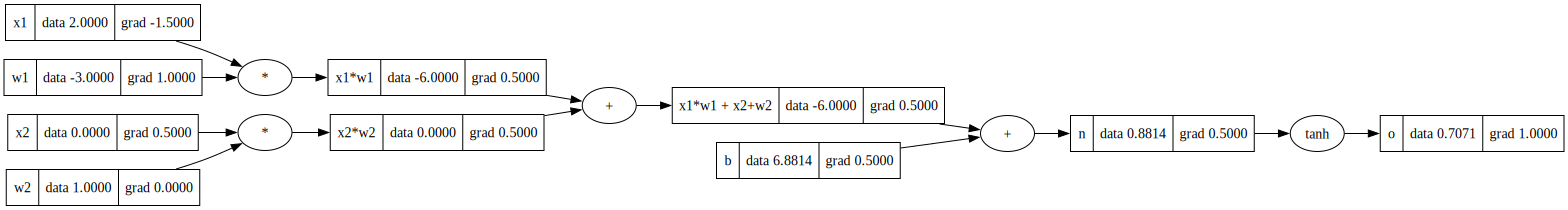

In [95]:
draw_dot(o)

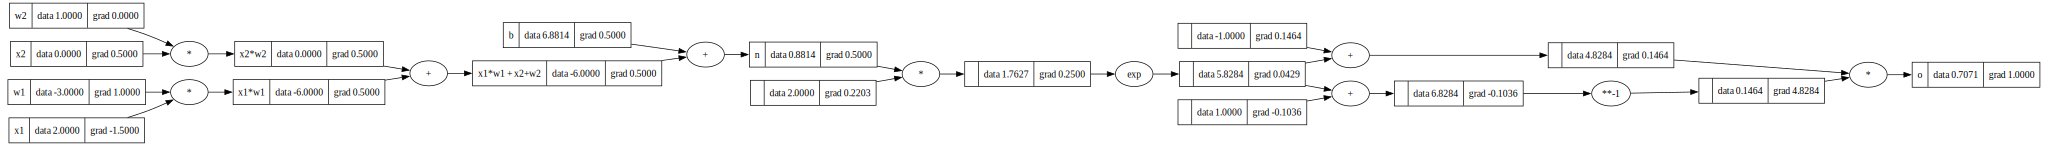

In [96]:
# Function example
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b') # weird ahh number
# x1*w1 + x2*w2 + b
# doing it in small steps so we have pointers to hold these intermediate nodes
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = "x1*w1 + x2+w2"
n = x1w1x2w2 + b; n.label = 'n'
# output, implement another tan h, tanh is a hyperbolic function, we need exponentiation, and also need divide
# -------- Change how we define o
e = (2*n).exp()
o = (e - 1) / (e + 1) # This is equivalent to tanh
# --------
# now tanh is a micrograd supportive node as an operation
# as long as we know the derivative of tanh, we can back propagate thru it
o.label = 'o'
o.backward()
draw_dot(o)


In [62]:
# # # Think through what we are doing, we laid out the mathametical expressions, and we are going backward through the expression
# # # Going through backward, we don't want to call ._backward() for any node before we have done everything after it
# # # Everything that it depends on has to propagate to it
# # # This ordering of graphs can be achieve through something called topological sort
# # # Topological Sort: "Before I calculate your gradient, make sure everyone that depends on you has already been calculated first"
# # # Automatically now
# # # o is the outcome of tanh, becareful, out.grad is initialized as 0.0
# # o.grad = 1.0 # Base case, initialize

# # topo = []
# # Visited = set() # Maintain a set of visited nodes
# # def build_topo(v): # going through starting at some sort of root node, in this case we start at o
# #     if v not in Visited:
# #         Visited.add(v) # If not 
# #         for child in v._prev:
# #             build_topo(child)
# #         topo.append(v)
# # build_topo(o) # Starting at o
# # # topo # Inspect the list

# # for node in reversed(topo):
# #     node._backward()

# # Hide this block of code, since you want it put it in the Value area

# o.backward()

In [63]:
# Automatically now
# o is the outcome of tanh, becareful, out.grad is initialized as 0.0
# o.grad = 1.0 # Base case, initialize

In [64]:
# o._backward() # This function works, n should be .5

In [65]:
# n._backward()

In [66]:
# b._backward() # nothing would happening, but we can call it
# x1w1x2w2._backward()

In [67]:
# x1w1._backward()
# x2w2._backward()

In [68]:
# # Back propagation time
# # Calcuate derivatives
# # What is O respect to O
# # Base case
# o.grad = 1.0
# n.grad = 0.5
# 1 - o.data**2 # o.data = 0.7071067811865476
# # 0.4999999999999999, .5 conviniently

# # Now back propagate thru tanh
# # o = tanh(n),,, Subtitute tanh(n) = o
# # do / dn = 1 - tanh(n)**2

# # Reminder a '+' node is a distributer of gradient, so the children woudl be the same as the parent
# # Childrens of n
# x1w1x2w2.grad = 0.5
# b.grad = 0.5

# # x2w2, x1w1 are also using '+', so x1w1x2w2 will distribute to them again
# x1w1.grad = 0.5
# x2w2.grad = 0.5

# # Calculate xs and ws
# x2.grad = w2.data * x2w2.grad # = 0.5
# w2.grad = x2.data * x2w2.grad # = 0.0

# x1.grad = w1.data * x1w1.grad # = -1.5
# w1.grad = x1.data * x1w1.grad # = 1.0

# # These grad numbers mean if we wiggle any of these they will have an impact on the final outcome
# # x2 grad will have a possitive outcome, making final higher
# # x1 grad will have a negative outcome, making final lower
# # if we wiggle w2, there will be no changes.

In [69]:
# # Conditions to think about
# # Gradient is not correct
# a = Value(3.0, label='a')
# b = a + a ; b.label = 'b' # b is the result of a + a
# b.backward()
# draw_dot(b)

In [70]:
# a = Value(-2.0, label='a')
# b = Value(3.0, label='b')
# d = a * b   ; d.label = 'd'
# e = a + b   ; e.label = 'e'
# f = d * e   ; f.label = 'f'
# # We see an issue everytime we use a variable more than once
# # Simple fix, add += rather than just set everything =
# # This is okay because we initialize the variables to 0 at first.
# # When using a variable for multiple different data, you just add their derivatives at the end together


# f.backward()

# draw_dot(f)

In [103]:
# Installed pytorch 
import torch

# python is by default using double precsion for floating point numbers
x1 = torch.Tensor([2.0]).double()               ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()               ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()              ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()               ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double() ; b.requires_grad = True
# These are leaf nodes, by deafult pytorch assume that these do not require gradiants,
# so we have to simply say that these nodes require grad using .requires_grad = True
# Constructs scalar-valued one element tensors
# After defining values, we can perform arithmetics, just like micrograd
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

# we need to call .item(), it basically takes a single tensor of one element and returns that element stripping out the tensor
print(o.data.item())
o.backward()

print("----")
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

# Tensors are n-dimensional array of scalars
# micrograd is only scalar-valued engine
# Pytorch is more efficient

0.7071066904050358
----
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [104]:
o # tensor object, and got backward function

tensor([0.7071], dtype=torch.float64, grad_fn=<TanhBackward0>)

In [105]:
o.item()

0.7071066904050358

In [101]:
# You can create more complicated tensors like
torch.Tensor([[1, 2, 3], [4, 5, 6]]) # This tensor is a 2 by 3 of scalars in a single compact representation
torch.Tensor([2.0]).double().dtype # By default this is float 32,
#                                   Casting double() will make it float 64 just like python

torch.float64

In [428]:
# Neural Networks, specific class of mathmetical expressions
# Multi-layered perceptron
# takes some inputs, multiplies each by weight, adds a bias, squishes through tanh(), one single calculation
class Neuron:

    def __init__(self, nin): # number of in puts to neuron, how many inputs to this neuron
        # nin is how many neuron 
        # Creates a weight some random num between -1, 1
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        # Creates a bias that controls the overall trigger happiness of this neuron
        self.b = Value(random.uniform(-1,1))

    def __call__(self, x):
        # w * x + b, w * x is a dot product specifically
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b) # Pair w up with x
        # zip(self.w, x) pairs each weight with its matching input
        # wi*xi multiplies each pair together
        # sum(..., self.b) adds them all up plus the bias
        # neuron activation
        out = act.tanh()
        # squishes the reuslt between -1 and 1
        return out

    def parameters(self): # return list + list
        return self.w + [self.b] # Returns parameters scalar


# A bunch of neurons sitting side by side, reciving same inputs with different weights
class Layer:

    def __init__(self, nin, nout):
        # nount neruons, each expecting nin inputs
        # so Layer(3, 4) = 4 neurons each taking 3 inputs
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        # Passes input x through every neuron
        # If only 1 neuron -> return just that value
        # If multiple neurons -> return the whole list
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]
        # Single list comprehension
        # way too much code
        # params = []
        # for neuron in self.neurons:
        #     ps = neuron.parameters()
        #     params.extend(ps)
        # return params

# A list of nouts, define the size of layers in MLP, the full network
# Input layer:      3 inputs
# Hidden layer 1:   4 neurons
# Hidden layer 2:   4 neurons
# Ouput layer:      1 neuron (final answer)
class MLP:

    def __init__(self, nin, nouts):
        # sz combines input size with layer sizes into one list
        # For MLP(3, [4, 4, 1]) -> sz = [3, 4, 4, 1]
        # Then creates layers by sliding a window of 2 across sz
        # Layer(3, 4) -> first layer
        # Layer(4, 4) -> second layer
        # Layer(4, 1) -> output layer
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    # calling them sequentially
    # Passes input through each layer one at a time
    # Output of one layer becomes input of next
    # Returns final output
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

# class Neuron defines a singular neuron
# class Layer is multiple neurons next to each other
# MLP is rows of layers of neurons, output depends on however many you define last

In [525]:
x = [2.0, 3.0, -1.0] # Three inputs
n = MLP(3, [4, 4, 1]) # Neuron is two dimensional in this case, since theres only two numbers
# Three inputs into two layers of 4 and one ouput
n(x)

Value(data=-0.4736263721607812)

In [ ]:
len(n.parameters()) # Weights and biases

41

In [ ]:
# Simple example
# Data definition
xs = [
    [2.0, 3.0, -1.0], # Four possible inputs into the neural net
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]

ys = [1.0, -1.0, -1.0, 1.0] # desired targets
ypred = [n(x) for x in xs] # Predictions
# [Value(data=0.98969663331814),    # want 1
#  Value(data=0.9756054667339605),  # want -1
#  Value(data=0.9768071209689313),  # want -1
#  Value(data=0.9679252122808948)]  # want 1
ypred

# Predictions are close now

[Value(data=0.9810858953227032),
 Value(data=-0.9835488564597571),
 Value(data=-0.9790674272580725),
 Value(data=0.9794144199794191)]

In [647]:
ypred = [n(x) for x in xs] # Predictions
# calculate the loss to get the desired outputs
# iterate for y ground truth, and y output in zip(ys, ypred)
loss = sum([(yout - ygt)**2 for ygt, yout in zip(ys, ypred)]) # Individual loss components
# mean squared error
# we want low loss
# Forward pass
loss

Value(data=0.0014903221859052416)

In [ ]:
# Training loop (important: zero grads each step)
# Continuously run this until value almost reaches 0
for k in range(20):
# Runs 20 training steps (20 gradient-descent updates) or however many you want
    # forward pass
    # Evaluate the loss
    ypred = [n(x) for x in xs]
    # runs the newtwork n on each input x to get predictions
    loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
    # compute total squared error across the dataset (MSE without the /N)

    # zero grad
    for p in n.parameters():
        # In micrograd, calling .backward() adds into .grad (it accumulates)
        # If you don't reset, tehn step 2's gradeints get added on top of step 1's,, step 3 adds
        # again, etc. That makes the updates effectively bigger and can make loss go up
        # This line makes each step use only the current step's gradients
        p.grad = 0.0 # resets grad to zero, just like in the constructor

    # backward pass
    loss.backward()
    # Computes partial derivative for loss and partial derivative for p, for every parameter  and stores it in p.grad

    # update
    lr = 0.01 # Learning rate (step size)
    for p in n.parameters():
        p.data += -lr * p.grad # this is gradient descent rule
    # p <-- p - lr * (partial derivative loss / partial derivative p)
    # p.grad points in the direction that increases loss most; subtracting it moves parameters to reduce loss

    if k % 5 == 0:
        print(k, loss.data)
    # Logging; prints the loss every 5 steps


0 0.00150361175539874
5 0.0015002673710151795
10 0.001496937712354919
15 0.0014936226826318707


In [651]:
# n.parameters() # Weights and biases that makes network predict the desire target very very close

In [520]:
loss

In [515]:
ypred

[Value(data=0.4240392982839206),
 Value(data=0.1180617458948764),
 Value(data=-0.33741030583465503),
 Value(data=0.3269075128700156)]

In [527]:
n.layers[0].neurons[0].w[0].grad
# Gradiant on the loss
# Slightly increasing the weight of the neuron of this layer
# Will make it go down
# -2.3193941976841717 in this example, the derivative of this neuron is negative,
# So having p.data += 0.01 * p.grad would increase the the data, the loss will go up
# Slightly increasing the neuron data will make the loss go down according to the gradient


0.0

In [526]:
n.layers[0].neurons[0].w[0].data # current value of this neuron

-0.9471681669776768

In [ ]:
# What are neural nets?
# Neural nets are these mathmetical expressions, very simple mathmetical expression in case of multi-layered perceptron
# That takes input as a data, and they takes input the weights and parameters
# of the neural net mathmetical expression for the forward pass followed by a loss function
# and the loss function try to messure the accuracy of the predictions and usually the loss will be low
# when your predictions are matching your targets, or your neural net behaving well
# We manipulate the loss fucntion, when the loss is low the network is doing waht you want it to do on your problem
# And then we backward the loss, using back propagation to get the gradient, then we know how to tune all the parameters
# to decrease the loss locally, then we have to iterate that process many time in whats called the gradient descent,
# we simply follow the gradient information and that minimizes the loss and the loss is arranged so when the loss is minimized
# the network is doing what you want it to do.
# We make neural network do their arbituary things